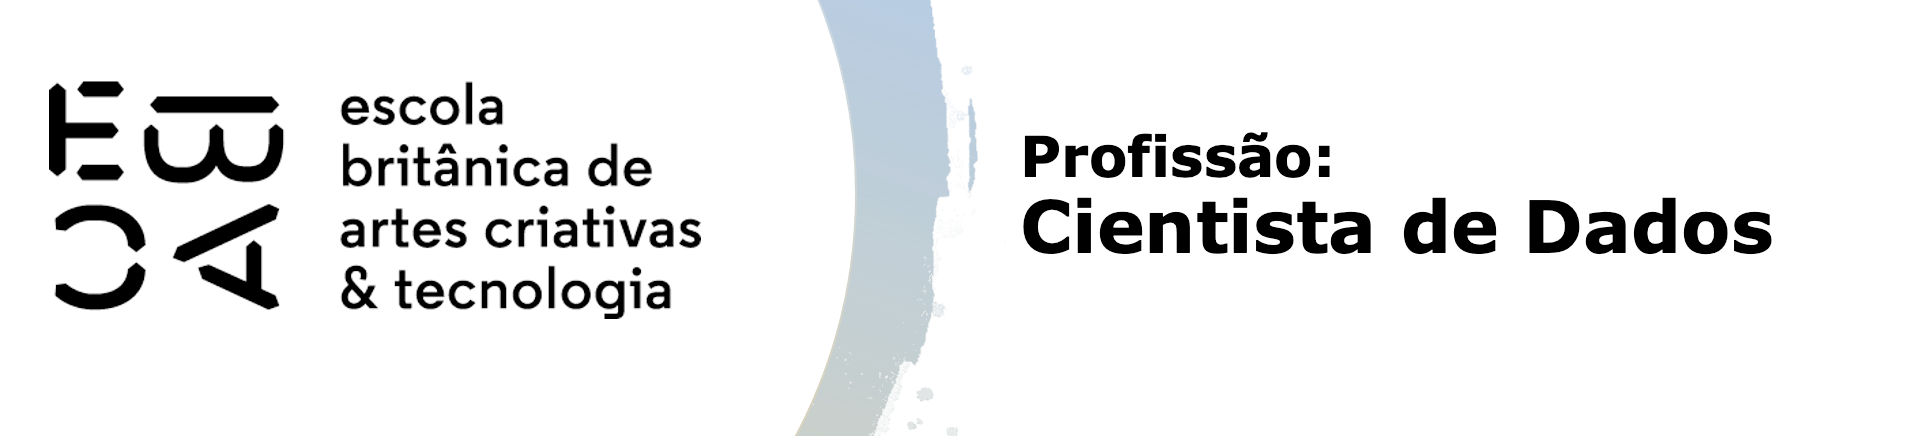

# Regressão III - Tarefa

In [164]:
# Importa o pandas para manipulação de dados tabulares
import pandas as pd
# Importa o numpy para operações numéricas e matemáticas
import numpy as np
# Importa o seaborn para visualização de dados estatísticos
import seaborn as sns
# Importa o matplotlib para criação de gráficos
import matplotlib.pyplot as plt
# Importa o statsmodels para modelagem estatística
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Importa a função de interpolação da scipy
from scipy.interpolate import interp1d
# Importa métricas de avaliação de modelos do scikit-learn
from sklearn.metrics import r2_score, mean_squared_error

In [165]:
df = pd.read_csv('./Dataset/previsao_de_renda_II.csv', index_col=0)
df.head()

,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda
data_ref,,,,,,,,,,,,,
2015-01-01,5762,M,S,N,0,Empresário,Superior completo,Casado,Casa,47,16.717808,2.0,11138.14
2015-01-01,1279,M,S,N,0,Assalariado,Superior incompleto,Casado,Casa,30,9.600000,2.0,2424.81
2015-01-01,14111,M,S,N,0,Assalariado,Superior completo,Casado,Casa,28,8.208219,2.0,13749.66
2015-01-01,8189,M,N,S,2,Assalariado,Médio,Casado,Casa,44,1.301370,4.0,2361.84
2015-01-01,1830,F,N,S,2,Assalariado,Superior completo,Casado,Casa,33,1.254795,4.0,790.78


## Avalie valores missing e substitua pela média

Neste exercício não vamos nos preocupar com valores *missing*. Substitua-os pela média.

In [166]:
df.isna().sum()

index                         0
sexo                          0
posse_de_veiculo              0
posse_de_imovel               0
qtd_filhos                    0
tipo_renda                    0
educacao                      0
estado_civil                  0
tipo_residencia               0
idade                         0
tempo_emprego            125760
qt_pessoas_residencia         0
renda                         0
dtype: int64

In [167]:
df.loc[df['tempo_emprego'].isna(), 'tempo_emprego'] = df['tempo_emprego'].mean()

In [168]:
df.isna().sum()

index                    0
sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
renda                    0
dtype: int64

### Base de testes

Separe os três últimos meses como base *holdout* (base de teste).

In [169]:
# Cria uma cópia do dataframe df com o índice resetado, transformando o índice em uma coluna normal
df = df.reset_index()

# Seleciona apenas as linhas cuja coluna 'data_ref' é maior ou igual a '2016-01-01'
df_last_three_months = df.loc[df['data_ref'] >= '2016-01-01']

# Exibe os valores únicos presentes na coluna 'data_ref' do dataframe filtrado
df_last_three_months.data_ref.unique()

array(['2016-01-01', '2016-02-01', '2016-03-01'], dtype=object)

In [170]:
df = df.loc[df['data_ref'] < '2016-01-01']
df['data_ref'].unique()

array(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
       '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
       '2015-09-01', '2015-10-01', '2015-11-01', '2015-12-01'],
      dtype=object)

### Primeiro modelo
 Não use *index* e não use a data. Avalie o modelo com o $R^2-ajustado$

In [171]:
variaveis = df.columns.to_list()

In [172]:
variaveis = [x for x in variaveis if x not in ['data_ref', 'index']]
variaveis

['sexo',
 'posse_de_veiculo',
 'posse_de_imovel',
 'qtd_filhos',
 'tipo_renda',
 'educacao',
 'estado_civil',
 'tipo_residencia',
 'idade',
 'tempo_emprego',
 'qt_pessoas_residencia',
 'renda']

### Análise de perfil

Categorize a variável ```tempo_emprego``` em 20 quantis (cada categoria deve ter aproximadamente a mesma quantidade de observações) e faça uma tabela de perfil (armazene como dataframe) para esta categorização:

- Cada linha é uma categoria
- Uma coluna para a quantidade de observações de cada categoria
- Uma coluna para a média do log-renda para cada categoria
- Uma coluna para a média do tempo de emprego para cada categoria

Faça um gráfico da média do tempo de emprego pela média do log-renda. Insira uma célula de texto e comente se te parece que alguma das transformações vistas no módulo deve fornecer bons resultados.

In [173]:
# Cria categorias (quantis) para a variável tempo_emprego, dividindo em 20 grupos aproximadamente iguais
grupos = pd.qcut(df.tempo_emprego, 20, duplicates='drop')

# Cria uma cópia do dataframe df apenas com as colunas selecionadas em 'variaveis'
tab = df[variaveis].copy()

# Cria uma nova coluna 'log_renda' aplicando o logaritmo natural à coluna 'renda'
# Se o valor de 'renda' for menor ou igual a zero, atribui 0 para evitar erro de logaritmo
tab['log_renda'] = tab['renda'].apply(lambda x : 0 if x <= 0 else np.log(x))

# Seleciona apenas as colunas numéricas do dataframe
tab = tab.select_dtypes(include=['float64', 'int64'])

# Agrupa o dataframe pelas categorias de tempo_emprego e calcula a média de cada coluna numérica para cada grupo
tab = tab.groupby(grupos).mean()

C:\Users\hfasa\AppData\Local\Temp\ipykernel_22332\433129684.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tab = tab.groupby(grupos).mean()


<Axes: xlabel='tempo_emprego', ylabel='renda'>

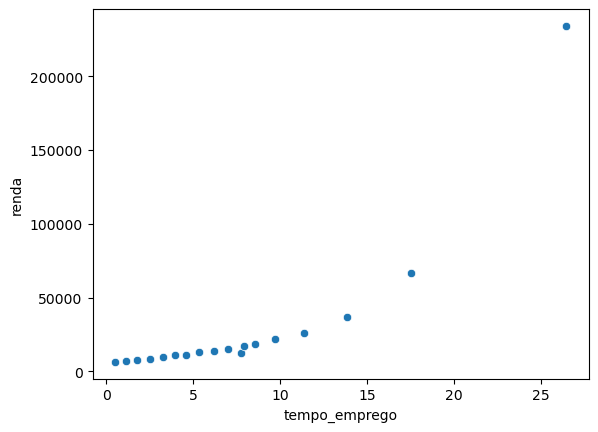

In [174]:
sns.scatterplot(data=tab, x='tempo_emprego', y='renda')

<Axes: xlabel='tempo_emprego', ylabel='log_renda'>

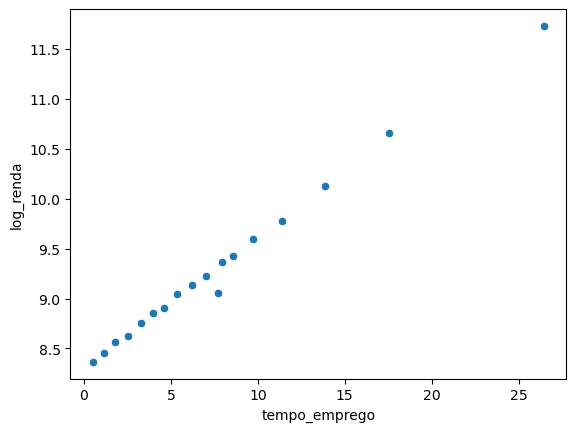

In [175]:
sns.scatterplot(data=tab, x='tempo_emprego', y='log_renda')

**Observação referente aos gráficos:** É notável o benefício que o uso da transformação logarírimica desempenhou na simetria de 'log_renda' com 'tempo_emprego', revelando um potencial escondido comparado a relação original

### Linearização

Experimente pelo menos duas técnicas de linearização vistas ao longo do módulo para melhorar o ajuste da variável ```tempo_emprego```. Compare o $R^2-ajustado$ e avalie se alguma delas apresentou resultados relevantes com relação ao primeiro modelo.


In [176]:
tab_viz = tab.copy()

In [177]:
def esp_vs_obs(data, res, X, y_pred, y_true):
    pred_ols = res.get_prediction()
    pred_summary = pred_ols.summary_frame()

    iv_l = pred_summary['obs_ci_lower']
    iv_u = pred_summary['obs_ci_upper']
    m_l = pred_summary['mean_ci_lower']
    m_u = pred_summary['mean_ci_upper']

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(data[X], y_pred, 'o', label="Dados observados", alpha=1)
    ax.plot(data[X], data[y_true], 'b-', label='Média da simulação')
    ax.plot(data[X], res.fittedvalues, 'r--', label='Estimativa OLS')
    ax.plot(data[X], iv_u, 'r--', label='Banda de confiança para y')
    ax.plot(data[X], iv_l, 'r--')
    ax.plot(data[X], m_u, 'g:', label='Banda de confiança para média')
    ax.plot(data[X], m_l, 'g:')
    ax.legend(loc='best')
    plt.show()


In [178]:
df1 = df.select_dtypes(['float64', 'int64'])
df1['log_renda'] =  np.log(df1['renda'])

In [179]:
res_tab = smf.ols('log_renda ~ tempo_emprego', data=tab).fit()
y_pred = res_tab.fittedvalues

In [180]:
print(f'R-Quadrado: {res_tab.rsquared:.2%}')
res_tab.summary()

R-Quadrado: 99.34%


c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2400.
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           7.28e-19
Time:                        19:28:05   Log-Likelihood:                 23.144
No. Observations:                  18   AIC:                            -42.29
Df Residuals:                      16   BIC:                            -40.51
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         8.3054      0.027    312.879      0.000       8.249       8.362
tempo_emprego     0.1302      0.003     48.992      0.000       0.125       0.136
==============================================================================
Omnibus:                       39.163   Durbin-Watson:                   2.202
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              105.156
Skew:                          -3.200   Prob(JB):                     1.46e-23
Kurtosis:                      12.963   Cond. No.                         16.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

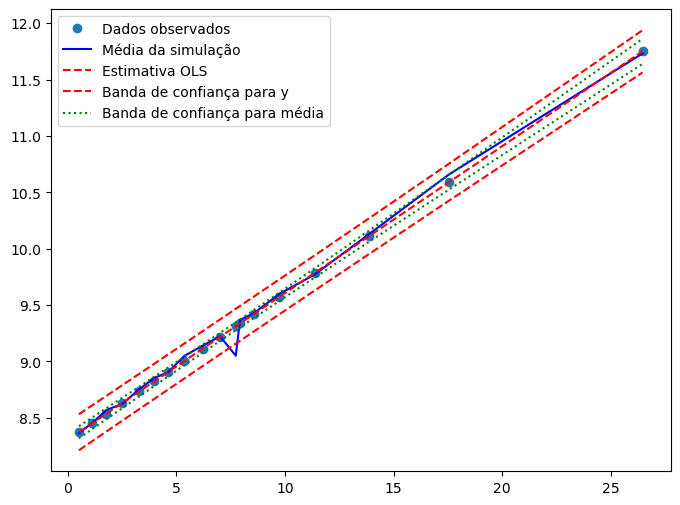

In [181]:
esp_vs_obs(data=tab, res=res_tab, X='tempo_emprego', y_true='log_renda', y_pred = y_pred)

R-quadrado: 99.34%


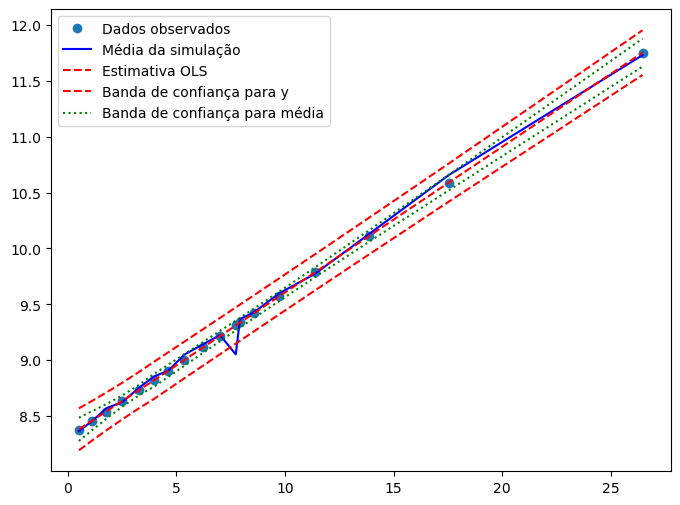

c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     1128.
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           4.46e-17
Time:                        19:28:06   Log-Likelihood:                 23.166
No. Observations:                  18   AIC:                            -40.33
Df Residuals:                      15   BIC:                            -37.66
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      8.3150      0.057    145.446      0.000       8.193       8.437
X1_1           0.1269      0.017      7.336      0.000       0.090       0.164
X1_2           0.1306      0.003     39.689      0.000       0.124       0.138
==============================================================================
Omnibus:                       38.193   Durbin-Watson:                   2.216
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.480
Skew:                          -3.127   Prob(JB):                     4.12e-22
Kurtosis:                      12.602   Cond. No.                         26.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [182]:
C1 = 4
tab_viz['X1'] = tab_viz['tempo_emprego']

tab_viz['X1_1'] = (tab_viz['X1'] <= C1) * tab_viz['X1'] + (tab_viz['X1']>C1) * C1
tab_viz['X1_2'] = (tab_viz['X1'] > C1)* (tab_viz['X1'] - C1)

res_segmentada = smf.ols(' log_renda ~ X1_1 + X1_2', data=tab_viz).fit()

print(f'R-quadrado: {res_segmentada.rsquared:.2%}')
esp_vs_obs(data=tab_viz, res=res_segmentada, X='X1', y_true='log_renda', y_pred = y_pred);
res_segmentada.summary()

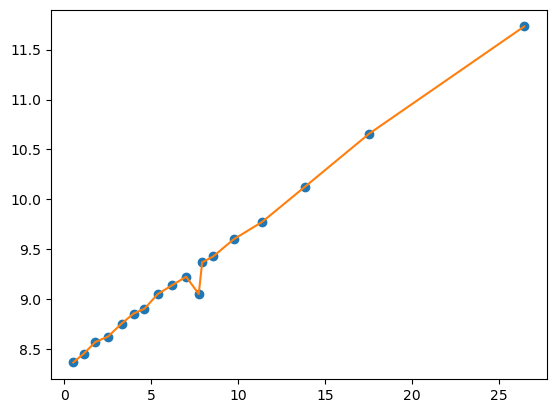

In [183]:
lowess = sm.nonparametric.lowess(tab_viz['log_renda'], tab_viz['X1'], frac=2/3)

lowess_y = lowess[:, 1]

lowess_x = lowess[:, 0]

fig, ax = plt.subplots()

ax.plot(tab_viz['X1'], tab_viz['log_renda'], 'o', label='Dados observados', alpha=1)
ax.plot(tab_viz['X1'], tab_viz['log_renda'], label='Lowess')

In [184]:
# Roda a interpolação do scipy
f = interp1d(lowess_x, lowess_y, bounds_error=False)

tab_viz['X1_lowess'] = f(tab_viz.X1)
tab_viz.head()


,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,log_renda,X1,X1_1,X1_2,X1_lowess
tempo_emprego,,,,,,,,,,
"(0.11699999999999999, 0.816]",0.579877,38.234537,0.515042,2.372263,6406.615090,8.364965,0.515042,0.515042,-0.0,8.372511
"(0.816, 1.458]",0.519630,39.351903,1.125014,2.247644,7316.772629,8.454323,1.125014,1.125014,-0.0,8.455296
"(1.458, 2.096]",0.526500,38.628027,1.781261,2.315812,8037.073066,8.569544,1.781261,1.781261,-0.0,8.544318
"(2.096, 2.912]",0.492387,38.704062,2.510920,2.305234,8674.879755,8.624148,2.510920,2.510920,-0.0,8.643310
"(2.912, 3.636]",0.512891,39.345633,3.301180,2.293607,9762.372783,8.755365,3.301180,3.301180,-0.0,8.750386


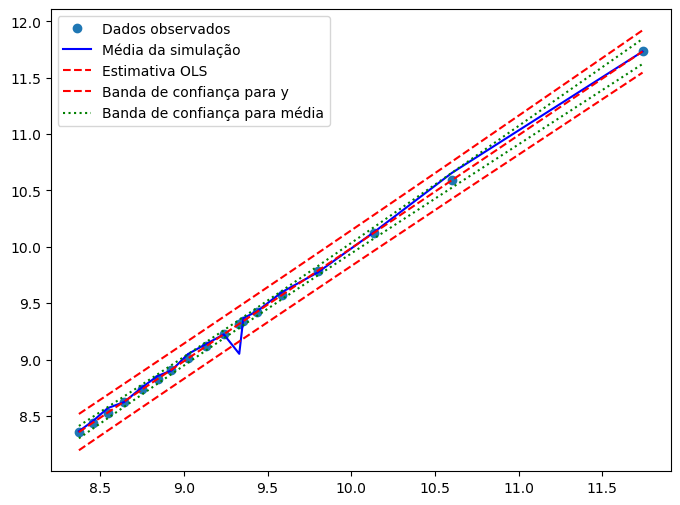

R-quadrado: 99.33%


c:\Users\hfasa\anaconda3\envs\EBAC\Lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              log_renda   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     2371.
Date:                Thu, 03 Jul 2025   Prob (F-statistic):           8.01e-19
Time:                        19:28:06   Log-Likelihood:                 23.036
No. Observations:                  18   AIC:                            -42.07
Df Residuals:                      16   BIC:                            -40.29
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0364      0.193     -0.189      0.853      -0.445       0.372
X1_lowess      1.0025      0.021     48.698      0.000       0.959       1.046
==============================================================================
Omnibus:                       41.009   Durbin-Watson:                   2.133
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              118.279
Skew:                          -3.346   Prob(JB):                     2.07e-26
Kurtosis:                      13.627   Cond. No.                         109.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [185]:
res_lowess = smf.ols('log_renda ~ X1_lowess',data=tab_viz).fit()
y_pred = res_lowess.fittedvalues

esp_vs_obs(data=tab_viz, res=res_lowess, X='X1_lowess', y_true='log_renda', y_pred = y_pred);
print(f'R-quadrado: {res_lowess.rsquared:.2%}')

res_lowess.summary()

### Avaliando o modelo

Avalie os resultados dos modelos construidos na base de testes.

In [ ]:
# Cria uma cópia do dataframe df_last_three_months apenas com as colunas selecionadas em 'variaveis'
tab_teste = df_last_three_months[variaveis].copy()

# Cria uma nova coluna 'log_renda' aplicando o logaritmo natural à coluna 'renda'
# Se o valor de 'renda' for menor ou igual a zero, atribui 0 para evitar erro de logaritmo
tab_teste['log_renda'] = tab_teste['renda'].apply(lambda x : 0 if x <= 0 else np.log(x))

# Seleciona apenas as colunas numéricas do dataframe para análise quantitativa
tab_teste = tab_teste.select_dtypes(include=['float64', 'int64'])

In [210]:
def esp_vs_obs(data, res, X, X1_1, X1_2, y_pred, y_true):
    pred_ols = res.get_prediction(data[['X1_1', 'X1_2']])
    pred_summary = pred_ols.summary_frame()

    iv_l = pred_summary['obs_ci_lower']
    iv_u = pred_summary['obs_ci_upper']
    m_l = pred_summary['mean_ci_lower']
    m_u = pred_summary['mean_ci_upper']

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.plot(data[X], y_pred, 'o', label="Dados observados", alpha=1)
    ax.plot(data[X], data[y_true], 'b-', label='Média da simulação')
    ax.plot(data[X], y_pred, 'r--', label='Estimativa OLS')
    ax.plot(data[X], iv_u, 'r--', label='Banda de confiança para y')
    ax.plot(data[X], iv_l, 'r--')
    ax.plot(data[X], m_u, 'g:', label='Banda de confiança para média')
    ax.plot(data[X], m_l, 'g:')
    ax.legend(loc='best')
    plt.show()

R-quadrado: -71.52%


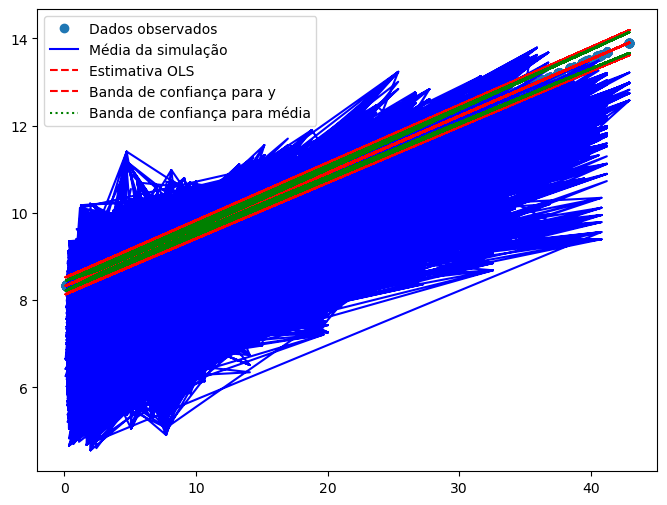

In [211]:
C1 = 4
tab_teste['X1'] = tab_teste['tempo_emprego']

tab_teste['X1_1'] = (tab_teste['X1'] <= C1) * tab_teste['X1'] + (tab_teste['X1']>C1) * C1
tab_teste['X1_2'] = (tab_teste['X1'] > C1)* (tab_teste['X1'] - C1)

y_pred = res_segmentada.predict(tab_teste[['X1_1', 'X1_2']])

print(f'R-quadrado: {r2_score(tab_teste['log_renda'], y_pred):.2%}')
esp_vs_obs(data=tab_teste,res=res_segmentada, X='X1', X1_1='X1_1', X1_2='X1_2', y_true='log_renda', y_pred=y_pred)
